# Colon somatic driver gene analysis

Python analysis associated with the MSc dissertation examining
somatic driver gene expression and damaging mutations in healthy
colon tissue.

## Data sources
- Human Protein Atlas: single-cell RNA-sequencing data
- NCG Healthy Drivers: somatic driver gene list
- SomaMutDB: healthy tissue somatic mutation data

In [1]:
# import lib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1. Data loading

In [2]:
#Create output folder

OUT = Path("/data/home/ha241113/ResearchProject/colon_pipeline_outputs")
# This defines the folder where all output files will be saved.

OUT.mkdir(exist_ok=True)
# This creates the output folder if it does not already exist.


In [3]:
#Load input data

# This loads the raw scRNA-seq read count matrix.
# Rows are genes, columns are cells, and values are raw RNA read counts.
read_count = pd.read_csv("/data/home/ha241113/ResearchProject/colon/read_count.tsv", sep="\t")

# This loads cell-level metadata.
# It contains cell ID, cluster assignment, and UMAP coordinates.
cell_data = pd.read_csv("/data/home/ha241113/ResearchProject/colon/cell_data.tsv", sep="\t")

# This loads the list of somatic driver genes across healthy tissues.
drivers = pd.read_csv("/data/home/ha241113/ResearchProject/somatic_drivers_healthy_tissue.tsv", sep="\t")

# This loads gene information used to convert gene symbols to Ensembl IDs.
gene_info = pd.read_csv("/data/home/ha241113/ResearchProject/NCG7_19756_GENE_INFO_TABLE_2020_08_04.tsv", sep='\t')

# This loads the official Human Protein Atlas cluster annotation table.
hpa_clusters = pd.read_csv("/data/home/ha241113/ResearchProject/rna_single_cell_clusters.tsv", sep="\t")

driver_roles = pd.read_csv(
    "/data/home/ha241113/ResearchProject/canonical_drivers_role.tsv",
    sep="\t"
)
# This loads the canonical cancer driver classifications.

print(read_count.shape)
print(cell_data.shape)
print("hpa_clusters shape:", hpa_clusters.shape)

(20162, 7340)
(7339, 4)
hpa_clusters shape: (1175, 8)


In [4]:
#read_count.head()

In [5]:
#cell_data.head()

In [6]:
#drivers.head()

In [7]:
#gene_info.head()

In [8]:
#hpa_clusters.head()

In [9]:
# how many genes and cells?
#print(read_count.shape)

# check gene column name
#print(read_count.columns[0])

# check if any missing values
#print(read_count.isna().sum().sum())

In [10]:
# how many clusters?
#print(cell_data["cluster"].nunique())

# how many cells per cluster?
#print(cell_data["cluster"].value_counts())

## 2. Single-cell expression preprocessing

In [11]:
# 3. Extract colon somatic driver genes

colon_drivers = drivers[drivers["organ"] == "colon"]
# This keeps only rows from the driver table where the organ is colon.

colon_driver_symbols = (
    colon_drivers["somatic_drivers"]
    .dropna()
    .astype(str)
    .unique()
)
# This extracts the colon driver gene symbols.
# dropna() removes missing values.
# astype(str) ensures gene names are treated as text.
# unique() removes duplicate gene names.

print("Colon driver gene symbols:")
# This prints a label for clarity.

print(colon_driver_symbols)
# This prints the selected colon driver genes.

print("Number of colon driver genes:", len(colon_driver_symbols))

Colon driver gene symbols:
['ARID1A' 'FBXW7' 'ERBB2' 'ERBB3' 'PIK3CA' 'AXIN2' 'STAG2' 'PIGR'
 'ZC3H12A']
Number of colon driver genes: 9


In [12]:
# 4. Map colon driver gene symbols to Ensembl IDs

driver_mapping = gene_info[
    gene_info["symbol"].isin(colon_driver_symbols)
][["symbol", "Ensembl_gene_identifier"]].drop_duplicates()
# The expression matrix uses Ensembl IDs, not gene symbols.
# This finds Ensembl IDs for the colon driver gene symbols.

driver_ensembl = (
    driver_mapping["Ensembl_gene_identifier"]
    .dropna()
    .unique()
)
# This extracts the Ensembl IDs for the colon driver genes.

print("Driver gene mapping:")
# This prints a label before the mapping table.

print(driver_mapping)
# This shows the gene symbol to Ensembl ID mapping.

print("Number of mapped colon driver genes:", len(driver_ensembl))
# This prints how many colon driver genes were successfully mapped.

Driver gene mapping:
        symbol Ensembl_gene_identifier
5242     ERBB2         ENSG00000141736
5243     ERBB3         ENSG00000065361
5739     AXIN2         ENSG00000168646
6744    PIK3CA         ENSG00000121879
7071     STAG2         ENSG00000101972
8078    ARID1A         ENSG00000117713
9232     FBXW7         ENSG00000109670
12476  ZC3H12A         ENSG00000163874
17352     PIGR         ENSG00000162896
Number of mapped colon driver genes: 9


In [13]:
# 5. Prepare the full expression count matrix

gene_col = "gene\\cell_id"
# This is the name of the column in read_count that contains gene IDs.
# The double backslash is required because backslash is a special character in Python strings.

all_counts = read_count.set_index(gene_col)
# This moves the gene ID column into the dataframe index.
# After this, rows = genes and columns = cells.

all_counts = all_counts.apply(pd.to_numeric, errors="coerce")
# This converts all expression values to numbers.

all_counts = all_counts.fillna(0)
# This replaces missing or invalid values with 0.

all_counts = all_counts.astype("float32")
# This reduces memory usage.

print("All-gene count matrix shape:")
# This prints a label before showing matrix size.

print(all_counts.shape)
# Expected shape is approximately genes x cells.

All-gene count matrix shape:
(20162, 7339)


In [14]:
# ============================================================
# Check which mapped colon driver genes are present in expression matrix
# ============================================================

driver_check = driver_mapping.copy()
# This copies the driver symbol to Ensembl ID mapping table.

driver_check["present_in_expression_matrix"] = (
    driver_check["Ensembl_gene_identifier"]
    .isin(all_counts.index)
)
# This checks whether each mapped driver Ensembl ID is present in the full expression matrix.

#print(driver_check)
# This prints each driver gene and whether it is present in the expression matrix.

print("Total colon driver genes:", len(colon_driver_symbols))
print("Mapped colon driver genes:", driver_check["symbol"].nunique())
print(
    "Driver genes present in expression matrix:",
    driver_check["present_in_expression_matrix"].sum()
)

Total colon driver genes: 9
Mapped colon driver genes: 9
Driver genes present in expression matrix: 9


In [15]:
# 6. Calculate library size for each cell

library_size = all_counts.sum(axis=0)
# This sums counts across all genes for each cell.
# Because cells are columns, axis=0 gives one total per cell.

print("Library size calculated.")
# This confirms the step is complete.

print(library_size.head())
# This displays the first few library size values.

Library size calculated.
1     4116.0
2      894.0
3     2136.0
4     9006.0
5    16313.0
dtype: float32


In [16]:
# 7. Normalise gene expression
# Used for cell-type annotation

all_norm = all_counts.div(library_size, axis=1) * 10000
# This performs library-size normalisation.
# Each gene count is divided by the total counts in that cell.
# Multiplication by 10,000 gives counts per 10,000 reads.

all_log_norm = np.log1p(all_norm)
# This applies log(1 + x) transformation.
# It reduces the effect of very large values and keeps zero values as zero.

print("All-gene log-normalised matrix shape:")
# This prints a label before showing the matrix size.

print(all_log_norm.shape)
# The shape is still genes x cells.

All-gene log-normalised matrix shape:
(20162, 7339)


In [17]:
#8 Add cluster information to each cell

all_log_norm_cell = all_log_norm.T
# This transposes the normalised expression matrix.
# Before transpose: rows = genes, columns = cells.
# After transpose: rows = cells, columns = genes.
# This is needed so each cell can be linked to its cluster.

cell_data["cell_id"] = cell_data["cell_id"].astype(str)
# This converts cell IDs in the metadata table to strings.
# This avoids matching problems caused by one table using numbers and another using text.

all_log_norm_cell.index = all_log_norm_cell.index.astype(str)
# This converts cell IDs in the expression table index to strings.
# Now both tables store cell IDs in the same format.

cluster_map = cell_data.set_index("cell_id")["cluster"]
# This creates a lookup table where index = cell_id and value = cluster.

all_log_norm_cell["cluster"] = all_log_norm_cell.index.map(cluster_map)
# This adds cluster labels to the expression table.
# For each cell, it looks up the matching cluster using cluster_map.

missing_cluster_labels = all_log_norm_cell["cluster"].isna().sum()
# This counts how many cells could not be matched to a cluster.

print("Missing cluster labels:", missing_cluster_labels)
# This prints the number of unmatched cells.

Missing cluster labels: 0


In [18]:
# 9.Calculate average expression per cluster

cluster_avg_all_genes = all_log_norm_cell.groupby("cluster").mean()
# This groups cells by cluster and calculates mean expression of each gene.
# Result: rows = clusters, columns = genes.

print("Cluster-average all-gene matrix shape:")
# This prints a label before showing the matrix size.

print(cluster_avg_all_genes.shape)
# Expected shape is number of clusters x number of genes.

Cluster-average all-gene matrix shape:
(25, 20162)


In [19]:
# 10. Extract colon driver gene expression per cluster

cluster_driver_expr = cluster_avg_all_genes[
    cluster_avg_all_genes.columns.intersection(driver_ensembl)
].copy()
# This keeps only colon driver genes from the cluster average table.

ensembl_to_driver_symbol = dict(
    zip(
        driver_mapping["Ensembl_gene_identifier"],
        driver_mapping["symbol"]
    )
)
# This creates a dictionary for renaming Ensembl IDs to gene symbols.

cluster_driver_expr = cluster_driver_expr.rename(columns=ensembl_to_driver_symbol)
# This renames driver gene columns from Ensembl IDs to readable gene symbols.

print("Cluster-level driver expression matrix shape:")
# This prints a label before showing the matrix size.

print(cluster_driver_expr.shape)
# Expected shape is number of clusters x number of colon driver genes.

print(cluster_driver_expr.head())
# This displays the first few rows.

Cluster-level driver expression matrix shape:
(25, 9)
gene\cell_id     ERBB3     STAG2     FBXW7    ARID1A    PIK3CA     ERBB2  \
cluster                                                                    
0             0.384362  0.262491  0.783131  0.211507  0.047409  0.209748   
1             0.214834  0.294932  0.713756  0.198404  0.082368  0.209820   
2             0.154373  0.400758  0.623796  0.353839  0.090011  0.290604   
3             0.168507  0.167546  0.719860  0.122768  0.059500  0.252490   
4             0.168068  0.184281  0.508965  0.178264  0.055112  0.300055   

gene\cell_id      PIGR   ZC3H12A     AXIN2  
cluster                                     
0             2.553821  0.278226  0.018355  
1             2.529281  0.218257  0.023528  
2             2.969916  0.415614  0.125341  
3             3.453099  0.197189  0.008384  
4             3.669293  0.186218  0.018917  


## 3. Cell-type annotation

In [20]:
# 11. Prepare HPA colon cluster annotations

colon_hpa_clusters = hpa_clusters[hpa_clusters["Tissue"] == "colon"].copy()
# This filters the HPA annotation table to keep colon clusters only.

print("Colon HPA cluster annotations:")
# This prints a label before showing the colon annotation table.

print(colon_hpa_clusters.head())
# This displays the first few colon annotation rows.

print("Colon annotation columns:")
# This prints a label before showing column names.

print(colon_hpa_clusters.columns)
# This helps verify that expected annotation columns are present.

Colon HPA cluster annotations:
    Tissue Cluster           Cell type  \
263  colon     c-0         colonocytes   
264  colon     c-1         colonocytes   
265  colon     c-2  enteric stem cells   
266  colon     c-3         colonocytes   
267  colon     c-4         colonocytes   

                                  Cell type detail  \
263  early differentiating colonocytes (mid-crypt)   
264  early differentiating colonocytes (mid-crypt)   
265                             enteric stem cells   
266  early differentiating colonocytes (mid-crypt)   
267        mature colonocytes (surface epithelium)   

                  Cell type class  Cell count Included in aggregation  \
263    glandular epithelial cells         765                     yes   
264    glandular epithelial cells         670                     yes   
265  stem and proliferating cells         657                     yes   
266    glandular epithelial cells         592                     yes   
267    glandular epithelia

In [21]:
#12. Create cluster labels matching HPA format
cluster_driver_expr_annotated = cluster_driver_expr.copy()
# This creates a copy of the driver expression table.

cluster_driver_expr_annotated["cluster_number"] = cluster_driver_expr_annotated.index
# This stores the original numeric cluster number in a new column.

cluster_driver_expr_annotated["Cluster"] = (
    "c-" + cluster_driver_expr_annotated.index.astype(str)
)
# HPA cluster IDs use the format c-0, c-1, c-2.
# This converts numeric clusters into the HPA format.

In [22]:
# 13  Merge driver expression with HPA annotations

annotation_columns = [
    "Cluster",
    "Cell type",
    "Cell type detail",
    "Cell type class",
    "Cell count",
    "Included in aggregation",
    "Annotation reliability"
]
# These are the HPA annotation columns we want to keep.

cluster_driver_expr_annotated = cluster_driver_expr_annotated.merge(
    colon_hpa_clusters[annotation_columns],
    on="Cluster",
    how="left"
)
# This merges driver expression with HPA annotations using the Cluster column.
# how="left" keeps all clusters from the expression table.

missing_hpa_annotations = cluster_driver_expr_annotated["Cell type"].isna().sum()
# This counts clusters that did not receive a HPA cell-type label.

print("Missing HPA annotations:", missing_hpa_annotations)
# This prints the number of unmatched clusters.

print(cluster_driver_expr_annotated.head())
# This displays the first few rows of the annotated table.

Missing HPA annotations: 0
      ERBB3     STAG2     FBXW7    ARID1A    PIK3CA     ERBB2      PIGR  \
0  0.384362  0.262491  0.783131  0.211507  0.047409  0.209748  2.553821   
1  0.214834  0.294932  0.713756  0.198404  0.082368  0.209820  2.529281   
2  0.154373  0.400758  0.623796  0.353839  0.090011  0.290604  2.969916   
3  0.168507  0.167546  0.719860  0.122768  0.059500  0.252490  3.453099   
4  0.168068  0.184281  0.508965  0.178264  0.055112  0.300055  3.669293   

    ZC3H12A     AXIN2  cluster_number Cluster           Cell type  \
0  0.278226  0.018355               0     c-0         colonocytes   
1  0.218257  0.023528               1     c-1         colonocytes   
2  0.415614  0.125341               2     c-2  enteric stem cells   
3  0.197189  0.008384               3     c-3         colonocytes   
4  0.186218  0.018917               4     c-4         colonocytes   

                                Cell type detail  \
0  early differentiating colonocytes (mid-crypt)   
1  

## 4. Expression analysis

In [23]:

# Create cell-type-level average expression table


# Get the names of the driver gene columns.
# These are the genes we want to plot.
driver_gene_cols = list(cluster_driver_expr.columns)

# Group clusters that have the same HPA cell type.
# For example, several clusters may all be labelled "colonocytes".
# This step averages those colonocyte clusters into one colonocyte row.
celltype_avg_expr = (
    cluster_driver_expr_annotated
    .groupby("Cell type")[driver_gene_cols]
    .mean()
)

# Display the new table.
# Rows are now HPA cell types instead of clusters.
# Columns are colon driver genes.
print(celltype_avg_expr.head())

# Save the cell-type-level average expression table.
celltype_avg_expr.to_csv(
    OUT / "colon_driver_average_expression_by_celltype.csv"
)

                                       ERBB3     STAG2     FBXW7    ARID1A  \
Cell type                                                                    
b-cells                             0.000000  0.655515  0.366629  0.457632   
colonocytes                         0.270081  0.227693  0.503116  0.154106   
enteric stem cells                  0.154373  0.400758  0.623796  0.353839   
enteric transient amplifying cells  0.137215  0.311871  0.637658  0.247447   
epithelial cells                    0.094981  0.377100  0.698547  0.510848   

                                      PIK3CA     ERBB2      PIGR   ZC3H12A  \
Cell type                                                                    
b-cells                             0.000000  0.000000  0.000000  0.358445   
colonocytes                         0.066204  0.255748  2.983513  0.214923   
enteric stem cells                  0.090011  0.290604  2.969916  0.415614   
enteric transient amplifying cells  0.089944  0.253569  2.89405

In [24]:
# 14. Save HPA-annotated driver expression table

cluster_driver_expr_annotated.to_csv(
    OUT / "colon_driver_average_expression_by_cluster_HPA_annotated.csv",
    index=False
)
# This saves average driver expression with official HPA annotations.

print("Saved HPA-annotated driver expression table.")
# This confirms that the annotated table was saved.

Saved HPA-annotated driver expression table.


In [25]:
# 15. Order clusters by HPA cell type class and cell type

cell_class_order = [
    "specialized epithelial cells",
    "glandular epithelial cells",
    "stem and progenitor cells",
    "endocrine cells",
    "blood and immune cells",
    "mesenchymal cells",
    "endothelial cells",
    "other"
]
# This defines a broad biological order for plotting.

cluster_driver_expr_annotated["Cell type class ordered"] = pd.Categorical(
    cluster_driver_expr_annotated["Cell type class"],
    categories=cell_class_order,
    ordered=True
)
# This converts Cell type class into an ordered category.

cluster_driver_expr_annotated = cluster_driver_expr_annotated.sort_values(
    ["Cell type class ordered", "Cell type", "cluster_number"]
)
# This sorts clusters by broad cell type class, then specific cell type, then cluster number.

ordered_clusters = cluster_driver_expr_annotated["cluster_number"].tolist()
# This extracts the sorted cluster numbers for plotting.

ordered_cluster_labels = cluster_driver_expr_annotated["Cluster"].tolist()
# This extracts sorted HPA-style cluster labels.

print("Ordered clusters:")
# This prints a label before showing the cluster order.

print(ordered_clusters)
# This displays the order used in plots.

Ordered clusters:
[17, 24, 21, 0, 1, 3, 4, 5, 7, 10, 11, 15, 6, 8, 20, 23, 22, 19, 14, 16, 18, 2, 9, 12, 13]


In [26]:
# 16.  Calculate proportion of cells expressing each driver gene

driver_counts = all_counts.loc[driver_ensembl]
# This extracts raw counts for colon driver genes.

driver_counts_cell = driver_counts.T.copy()
# This transposes the driver count matrix so rows = cells and columns = genes.

driver_counts_cell.index = driver_counts_cell.index.astype(str)
# This converts cell IDs to strings.

driver_counts_cell["cluster"] = driver_counts_cell.index.map(cluster_map)
# This adds each cell's cluster label.

missing_driver_cluster_labels = driver_counts_cell["cluster"].isna().sum()
# This checks whether any cell failed to receive a cluster label.

print("Missing cluster labels in driver counts:", missing_driver_cluster_labels)
# This prints the number of missing cluster labels.

driver_detected = driver_counts_cell.drop(columns="cluster") > 0
# This converts raw counts into True/False values.
# True means the gene is detected in that cell.

driver_detected["cluster"] = driver_counts_cell["cluster"]
# This adds the cluster column back to the detection table.

cluster_driver_prop = driver_detected.groupby("cluster").mean()
# This calculates the proportion of cells expressing each driver gene in each cluster.

cluster_driver_prop = cluster_driver_prop.rename(columns=ensembl_to_driver_symbol)
# This renames driver gene columns from Ensembl IDs to gene symbols.

cluster_driver_prop = cluster_driver_prop.loc[ordered_clusters]
# This orders the proportion table using the same biological cluster order.

print("Proportion expressing table:")
# This prints a label before showing the proportion table.

print(cluster_driver_prop.head())
# This displays the first few rows.

Missing cluster labels in driver counts: 0
Proportion expressing table:
gene\cell_id     ERBB2     ERBB3     AXIN2    PIK3CA     STAG2    ARID1A  \
cluster                                                                    
17            0.351648  0.252747  0.131868  0.351648  0.758242  0.725275   
24            0.454545  0.090909  0.000000  0.636364  0.454545  0.727273   
21            0.042553  0.148936  0.000000  0.042553  0.063830  0.170213   
0             0.141176  0.233987  0.014379  0.030065  0.171242  0.150327   
1             0.189552  0.180597  0.026866  0.083582  0.256716  0.197015   

gene\cell_id     FBXW7   ZC3H12A      PIGR  
cluster                                     
17            0.747253  0.087912  0.021978  
24            0.818182  0.090909  0.000000  
21            0.212766  0.170213  0.170213  
0             0.439216  0.175163  0.874510  
1             0.492537  0.192537  0.920896  


In [27]:
# 17. Save proportion-expressing table

cluster_driver_prop.to_csv(
    OUT / "colon_driver_proportion_cells_expressing_by_cluster_HPA_ordered.csv"
)
# This saves the proportion of cells expressing each driver gene by cluster.

print("Saved proportion-expressing table.")
# This confirms the table was saved.

Saved proportion-expressing table.


In [28]:
# 18. Define colours for HPA cell type classes

cell_class_colors = {
    "specialized epithelial cells": "tab:blue",
    "glandular epithelial cells": "tab:green",
    "stem and proliferating cells": "dimgrey",
    "endocrine cells": "tab:orange",
    "blood and immune cells": "tab:red",
    "mesenchymal cells": "tab:purple",
    "endothelial cells": "tab:brown",
    "other": "tab:gold"
}
# This assigns one colour to each broad HPA cell type class.

cluster_to_class = dict(
    zip(
        cluster_driver_expr_annotated["cluster_number"],
        cluster_driver_expr_annotated["Cell type class"]
    )
)
# This creates a lookup from cluster number to HPA cell type class.

cluster_to_celltype = dict(
    zip(
        cluster_driver_expr_annotated["cluster_number"],
        cluster_driver_expr_annotated["Cell type"]
    )
)
# This creates a lookup from cluster number to specific HPA cell type.

In [29]:
# Order HPA cell types by cell type class

celltype_order_df = (
    cluster_driver_expr_annotated
    .drop_duplicates("Cell type")
    [["Cell type", "Cell type class"]]
    .copy()
)
# This keeps one row per HPA cell type with its broader HPA cell type class.

celltype_order_df["Cell type class ordered"] = pd.Categorical(
    celltype_order_df["Cell type class"],
    categories=cell_class_order,
    ordered=True
)
# This applies the biological ordering of HPA cell type classes.

ordered_celltypes = (
    celltype_order_df
    .sort_values(["Cell type class ordered", "Cell type"])
    ["Cell type"]
    .tolist()
)
# This creates the final y-axis order for the plot.

In [30]:
driver_roles = driver_roles[
    ["symbol", "Canonical_Driver_Role"]
]
# This keeps only the gene symbol and driver role columns.

role_lookup = dict(
    zip(
        driver_roles["symbol"],
        driver_roles["Canonical_Driver_Role"]
    )
)
# This creates a lookup table:
# gene -> oncogene / TSG

print(role_lookup.get("PIK3CA"))
print(role_lookup.get("FBXW7"))

oncogene
TSG


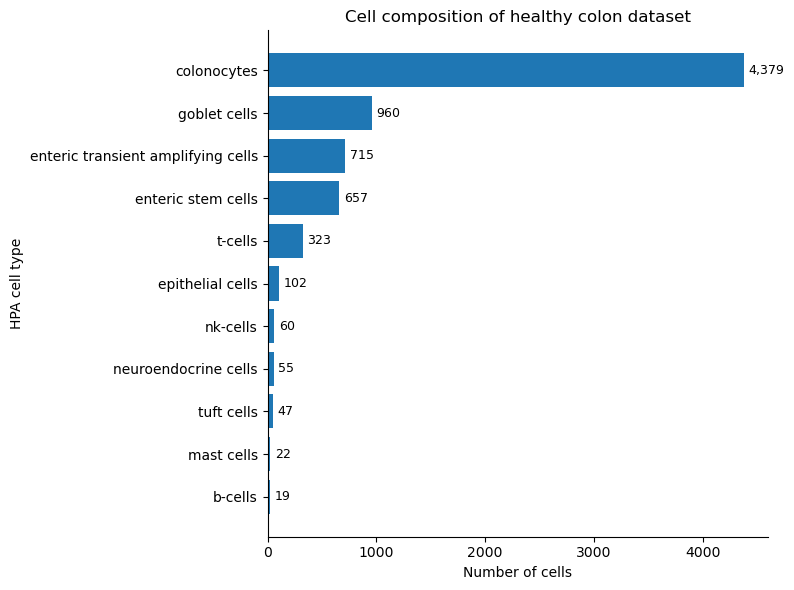

In [31]:
# ============================================================
# Number of cells per HPA cell type
# Horizontal bar plot
# ============================================================

# Use annotated cluster-level table
# This already contains: Cluster, Cell type, Cell type class, Cell count

cell_counts = (
    cluster_driver_expr_annotated
    .groupby("Cell type")["Cell count"]
    .sum()
    .sort_values(ascending=True)
)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.barh(
    cell_counts.index,
    cell_counts.values
)

# Add count labels
for bar in bars:

    width = bar.get_width()

    ax.text(
        width + max(cell_counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=9
    )

# Labels
ax.set_xlabel("Number of cells")
ax.set_ylabel("HPA cell type")
ax.set_title("Cell composition of healthy colon dataset")

# Clean plot
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    OUT / "colon_cell_type_counts_horizontal_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

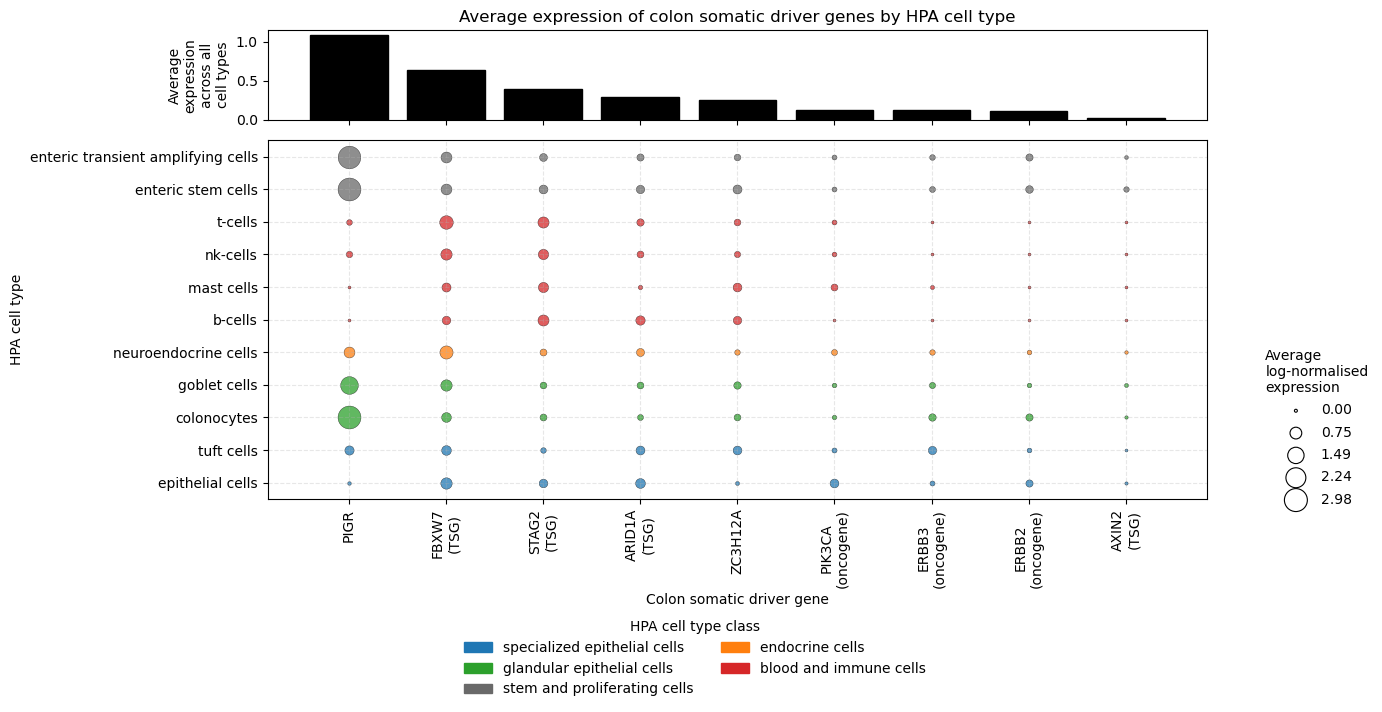

In [32]:
# 19. Plot average expression of colon driver genes by HPA cell type

driver_gene_cols = list(cluster_driver_expr.columns)
# This stores the driver gene columns.

celltype_avg_expr = (
    cluster_driver_expr_annotated
    .groupby("Cell type")[driver_gene_cols]
    .mean()
)
# This groups clusters with the same HPA cell type into one row.

celltype_order_df = (
    cluster_driver_expr_annotated
    .drop_duplicates("Cell type")
    [["Cell type", "Cell type class"]]
    .copy()
)
# This keeps one row per HPA cell type with its broader HPA cell type class.

celltype_order_df["Cell type class ordered"] = pd.Categorical(
    celltype_order_df["Cell type class"],
    categories=cell_class_order,
    ordered=True
)
# This applies the HPA cell type class order.

ordered_celltypes = (
    celltype_order_df
    .sort_values(["Cell type class ordered", "Cell type"])
    ["Cell type"]
    .tolist()
)
# This orders HPA cell types so similar cells are grouped together.

celltype_avg_expr = celltype_avg_expr.loc[
    [ct for ct in ordered_celltypes if ct in celltype_avg_expr.index]
]
# This applies the ordered HPA cell type order to the expression table.

gene_order = (
    celltype_avg_expr
    .mean(axis=0)
    .sort_values(ascending=False)
    .index
    .tolist()
)
# This orders genes from most expressed to least expressed.

celltype_avg_expr = celltype_avg_expr[gene_order]
# This applies the gene order to the table.

plot_data = celltype_avg_expr.T
# This transposes the table so rows = genes and columns = HPA cell types.

genes = plot_data.index.tolist()
# This stores ordered driver gene names for the x-axis.

gene_roles = [
    role_lookup.get(gene, "")
    for gene in genes
]
# This gets the canonical driver role for each plotted gene.

celltypes = plot_data.columns.tolist()
# This stores ordered HPA cell type names for the y-axis.

celltype_to_class = (
    cluster_driver_expr_annotated
    .drop_duplicates("Cell type")
    .set_index("Cell type")["Cell type class"]
    .to_dict()
)
# This maps each HPA cell type to its broader HPA cell type class.

gene_means = plot_data.mean(axis=1)
# This calculates the mean expression of each driver gene across HPA cell types.

fig_height = max(7, len(celltypes) * 0.55)
# This increases plot height when there are many cell types.

fig, (ax_bar, ax_dot) = plt.subplots(
    2,
    1,
    figsize=(14, fig_height),
    gridspec_kw={"height_ratios": [1, 4]},
    sharex=True
)
# This creates a larger two-panel figure to reduce overlap.

ax_bar.bar(
    range(len(genes)),
    gene_means,
    color="black",
    edgecolor="black"
)
# This draws the top bar plot in grey so it does not overlap visually with HPA cell type colours.

ax_bar.set_ylabel("Average\nexpression\nacross all\ncell types")
# This labels the y-axis of the bar plot.

ax_bar.set_title("Average expression of colon somatic driver genes by HPA cell type")
# This adds a title.

for x, gene in enumerate(genes):
    # This loops through each driver gene.

    for y, celltype in enumerate(celltypes):
        # This loops through each HPA cell type.

        value = plot_data.loc[gene, celltype]
        # This gets the average expression value for this gene and HPA cell type.

        cell_class = celltype_to_class[celltype]
        # This gets the HPA cell type class for this cell type.

        colour = cell_class_colors.get(cell_class, "tab:gray")
        # This gets the colour for the HPA cell type class.

        ax_dot.scatter(
            x,
            y,
            s=(value + 0.05) * 90,
            color=colour,
            alpha=0.75,
            edgecolor="black",
            linewidth=0.3
        )
        # This draws one dot.
        # Dot size = average expression.
        # Dot colour = HPA cell type class.

ax_dot.set_xticks(range(len(genes)))
# This sets x-axis tick positions.

xtick_labels = [
    f"{gene}\n({role})"
    if role != ""
    else gene
    for gene, role in zip(genes, gene_roles)
]
# This combines the gene name and its canonical driver role.

ax_dot.set_xticklabels(
    xtick_labels,
    rotation=90
)

ax_dot.set_yticks(range(len(celltypes)))
# This sets y-axis tick positions.

ax_dot.set_yticklabels(celltypes)
# This labels the y-axis using grouped HPA cell types.

ax_dot.set_xlabel("Colon somatic driver gene")
# This labels the x-axis.

ax_dot.set_ylabel("HPA cell type")
# This labels the y-axis.

ax_dot.grid(True, linestyle="--", alpha=0.3)
# This adds a light grid to make the plot easier to read.

legend_handles = [
    mpatches.Patch(color=color, label=cell_class)
    for cell_class, color in cell_class_colors.items()
    if cell_class in celltype_to_class.values()
]
# This creates legend boxes for HPA cell type classes present in the data.

fig.legend(
    handles=legend_handles,
    title="HPA cell type class",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)
# This adds the HPA cell type class legend below the whole figure.


max_expr = plot_data.max().max()
# This finds the highest average expression value in the plot.

size_values = np.linspace(0, max_expr, 5)
# This creates five evenly spaced expression values from 0 to the maximum.

size_handles = [
    ax_dot.scatter(
        [],
        [],
        s=(v + 0.05) * 90,
        facecolors="none",
        edgecolors="black",
        linewidth=0.8
    )
    for v in size_values
]
# This creates empty example circles for the dot-size legend.

size_labels = [
    f"{v:.2f}"
    for v in size_values
]
# This formats the expression values to two decimal places.

#ax_dot.add_artist(colour_legend)
# This keeps the HPA cell type class colour legend when adding the size legend.

ax_dot.legend(
    size_handles,
    size_labels,
    title="Average\nlog-normalised\nexpression",
    bbox_to_anchor=(1.05, 0.45),
    loc="upper left",
    frameon=False,
    labelspacing=0.6,
    handletextpad=0.8,
    borderpad=0.3
)
# This adds a vertical dot-size legend.
plt.tight_layout()
# This adjusts spacing.

plt.subplots_adjust(bottom=0.28)
# This adds extra space at the bottom for the HPA cell type class legend.

plt.savefig(
    OUT / "colon_driver_average_expression_by_celltype_ordered_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)
# This saves the improved average expression dot plot.

plt.show()
# This displays the plot in Jupyter.

In [33]:
print(gene_means)

PIGR       1.094366
FBXW7      0.645317
STAG2      0.393871
ARID1A     0.292806
ZC3H12A    0.255050
PIK3CA     0.124538
ERBB3      0.122924
ERBB2      0.116636
AXIN2      0.023075
dtype: float32


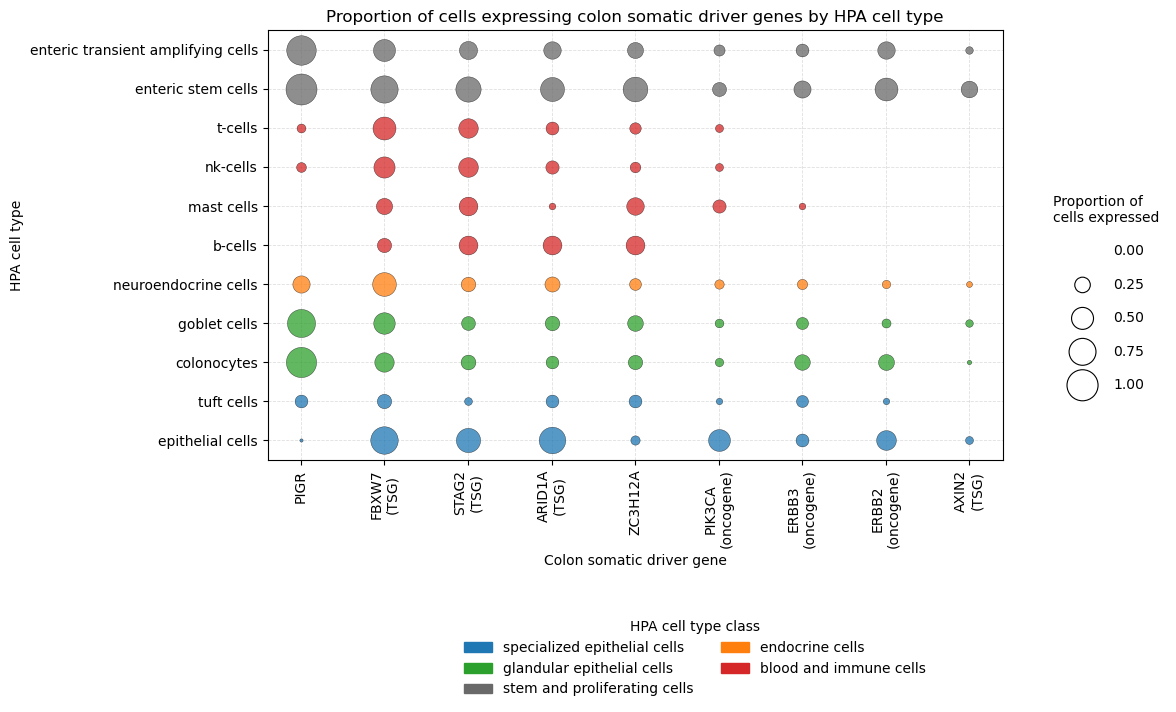

In [34]:
## Proportion of cells expressing plot grouped by HPA cell type

cluster_driver_prop_annotated = cluster_driver_prop.copy()
# This makes a copy of the cluster-level proportion table.

cluster_driver_prop_annotated["Cell type"] = (
    cluster_driver_prop_annotated.index.map(cluster_to_celltype)
)
# This adds HPA cell type labels to each cluster.

celltype_prop_expr = (
    cluster_driver_prop_annotated
    .groupby("Cell type")[driver_gene_cols]
    .mean()
)
# This groups clusters by HPA cell type and calculates the mean proportion expressing each driver gene.

celltype_prop_expr = celltype_prop_expr.loc[
    [ct for ct in ordered_celltypes if ct in celltype_prop_expr.index]
]
# This orders HPA cell types by HPA cell type class so similar cell types stay together.

celltype_prop_expr = celltype_prop_expr[gene_order]
# This orders genes from least expressed to most expressed using the same order as the average-expression plot.

celltype_prop_expr.to_csv(
    OUT / "colon_driver_proportion_expressing_by_celltype_ordered.csv"
)
# This saves the grouped and ordered proportion-expressing table.

prop_plot = celltype_prop_expr.T
# This transposes the table so rows = genes and columns = HPA cell types.

genes = prop_plot.index.tolist()
# This stores ordered driver gene names for the x-axis.

celltypes = prop_plot.columns.tolist()
# This stores ordered HPA cell type names for the y-axis.

fig_height = max(7, len(celltypes) * 0.55)
# This increases plot height when there are many cell types.

fig, ax = plt.subplots(figsize=(14, fig_height))
# This creates a larger figure to reduce circle overlap.

for x, gene in enumerate(genes):
    # This loops through each driver gene.

    for y, celltype in enumerate(celltypes):
        # This loops through each HPA cell type.

        proportion = prop_plot.loc[gene, celltype]
        # This gets the proportion of cells expressing this gene in this cell type.

        cell_class = celltype_to_class[celltype]
        # This gets the broader HPA cell type class for this cell type.

        colour = cell_class_colors.get(cell_class, "tab:gray")
        # This assigns a colour based on HPA cell type class.

        ax.scatter(
            x,
            y,
            s=proportion * 500,
            color=colour,
            alpha=0.75,
            edgecolor="black",
            linewidth=0.3
        )
        # This plots one dot where dot size represents proportion of cells expressing the gene.

ax.set_xticks(range(len(genes)))
# This sets x-axis tick positions for each driver gene.

xtick_labels = [
    f"{gene}\n({role_lookup.get(gene)})"
    if role_lookup.get(gene) is not None
    else gene
    for gene in genes
]
# This adds the canonical driver role underneath genes that are
# classified as oncogenes or tumour suppressor genes.
# Genes not present in the canonical driver list (e.g. PIGR, ZC3H12A)
# are displayed without brackets.

ax.set_xticklabels(
    xtick_labels,
    rotation=90
)
# This labels the x-axis with gene names and canonical driver roles.

ax.set_yticks(range(len(celltypes)))
# This sets y-axis tick positions for each HPA cell type.

ax.set_yticklabels(celltypes)
# This labels the y-axis with grouped HPA cell type names.

ax.set_xlabel("Colon somatic driver gene")
# This labels the x-axis.

ax.set_ylabel("HPA cell type")
# This labels the y-axis.

ax.set_title(
    "Proportion of cells expressing colon somatic driver genes by HPA cell type"
)
# This adds the plot title.

ax.set_axisbelow(True)
# This sends the grid behind the dots.

ax.grid(
    True,
    which="major",
    axis="both",
    linestyle="--",
    linewidth=0.6,
    alpha=0.4
)
# This adds visible grid lines across both axes.

legend_handles = [
    mpatches.Patch(color=color, label=cell_class)
    for cell_class, color in cell_class_colors.items()
    if cell_class in celltype_to_class.values()
]
# This creates legend boxes for HPA cell type classes present in the data.

fig.legend(
    handles=legend_handles,
    title="HPA cell type class",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)
# This adds the HPA cell type class colour legend below the whole figure.

size_values = [0.00, 0.25, 0.50, 0.75, 1.00]
# These are example proportions for the circle-size legend.

size_scale = 500
# This controls the size of the legend circles.
# A slightly smaller value helps stop the legend circles from overlapping.

size_handles = [
    ax.scatter(
        [],
        [],
        s=v * size_scale,
        facecolors="none",
        edgecolors="black",
        linewidth=0.8
    )
    for v in size_values
]
# This creates empty example circles for the dot-size legend.

ax.legend(
    size_handles,
    [f"{v:.2f}" for v in size_values],
    title="Proportion of\ncells expressed",
    bbox_to_anchor=(1.05, 0.65),
    loc="upper left",
    frameon=False,
    labelspacing=1.4,
    handletextpad=1.2,
    borderpad=0.5
)
# This adds the circle-size legend with extra spacing so circles do not overlap.

plt.tight_layout(rect=[0, 0.16, 0.86, 1])
# This adjusts spacing while leaving room for bottom and right-side legends.

plt.savefig(
    OUT / "colon_driver_proportion_expressing_by_celltype_ordered_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)
# This saves the improved proportion-expressing dot plot.

plt.show()
# This displays the plot.

In [35]:
print(celltype_prop_expr)

gene\cell_id                            PIGR     FBXW7     STAG2    ARID1A  \
Cell type                                                                    
epithelial cells                    0.010989  0.782717  0.606394  0.726274   
tuft cells                          0.170213  0.212766  0.063830  0.170213   
colonocytes                         0.945214  0.388829  0.225999  0.167552   
goblet cells                        0.815369  0.478055  0.199014  0.218763   
neuroendocrine cells                0.309091  0.581818  0.218182  0.236364   
b-cells                             0.000000  0.210526  0.368421  0.368421   
mast cells                          0.000000  0.272727  0.363636  0.045455   
nk-cells                            0.100000  0.466667  0.400000  0.183333   
t-cells                             0.081504  0.547993  0.395212  0.172562   
enteric stem cells                  0.998478  0.771689  0.662100  0.596651   
enteric transient amplifying cells  0.902088  0.501047  0.339914

## 5. Mutation analysis

In [36]:
#pip install pyreadr

In [37]:
## adding mutation dataset

import pyreadr
# This imports the package used to read RDS files in Python.

results = pyreadr.read_r("/data/home/ha241113/ResearchProject/colon/annotated_mutations_normal_colon.rds")
# This reads the RDS file.

print(results.keys())
# This shows the names of objects stored inside the RDS file.


odict_keys([None])


In [38]:
#Extract the dataframe
mutation_data = results[None]
# This extracts the dataframe stored inside the RDS file.

In [39]:
#inspect dataset

#mutation_data.shape
# This shows number of rows and columns.



In [40]:
#mutation_data.head()
# This displays the first few rows.


In [41]:
# load metadata file

# Load healthy colon sample metadata

sample_metadata = pd.read_csv(
    "/data/home/ha241113/ResearchProject/colon/colon_healthy_samples_mutations.tsv",
    sep="\t"
)
# This loads the metadata table containing donor information.

sample_metadata = sample_metadata[
    [
        "Sample",
        "IndividualID",
        "Age",
        "Gender",
        "Paper"
    ]
].drop_duplicates()
# This keeps only the useful metadata columns.

print(sample_metadata.shape)
sample_metadata.head()


(1087, 5)


,Sample,IndividualID,Age,Gender,Paper
0,PD21928b3,PD21928,67,F,Tissue-specific mutation accumulation in human...
1,PD21928b4,PD21928,67,F,Tissue-specific mutation accumulation in human...
2,PD21928b5,PD21928,67,F,Tissue-specific mutation accumulation in human...
3,PD21928b6,PD21928,67,F,Tissue-specific mutation accumulation in human...
4,PD21928b7,PD21928,67,F,Tissue-specific mutation accumulation in human...


In [42]:
#merge datasets

mutation_data = mutation_data.merge(
    sample_metadata[
        ["Sample", "IndividualID", "Age", "Gender"]
    ],
    on="Sample",
    how="left"
)
# This adds donor information to every mutation.

print(
    mutation_data[
        ["Sample", "IndividualID"]
    ].head()
)

                  Sample IndividualID
0  PD34200_coloniccryptS      PD34200
1  PD34200_coloniccryptS      PD34200
2  PD34200_coloniccryptS      PD34200
3  PD34200_coloniccryptS      PD34200
4  PD34200_coloniccryptS      PD34200


In [43]:
print("Unique samples :", mutation_data["Sample"].nunique())
print("Unique donors  :", mutation_data["IndividualID"].nunique())

Unique samples : 1087
Unique donors  : 151


In [44]:
# Filter protein-changing mutations
# Keep only exonic or splicing mutations
protein_changing = mutation_data[
    mutation_data["Func.refGene"].isin(["exonic", "splicing"])
].copy()
# This keeps mutations that occur in coding or splice-related regions.

protein_changing = protein_changing[
    ~protein_changing["ExonicFunc.refGene"].isin(["synonymous", "unknown"])
].copy()
# This removes synonymous and unknown mutations because they do not clearly change the protein.

print(protein_changing.shape)
# This shows how many protein-changing mutations remain.

(24755, 28)


In [45]:
# Keep only colon driver genes

driver_mutations = protein_changing[
    protein_changing["symbol_19807"].isin(colon_driver_symbols)
].copy()
# This keeps only mutations in the colon driver genes of interest.

print(driver_mutations.shape)
# This shows how many protein-changing driver mutations are present.

(77, 28)


In [46]:
# Number of samples and donors with each mutated driver

driver_sample_counts = (
    driver_mutations
    .groupby("symbol_19807")["Sample"]
    .nunique()
    .reset_index(name="n_samples")
)
# This counts how many unique samples contain each mutated driver gene.

driver_donor_counts = (
    driver_mutations
    .groupby("symbol_19807")["IndividualID"]
    .nunique()
    .reset_index(name="n_donors")
)
# This counts how many unique donors contain each mutated driver gene.

driver_counts = driver_sample_counts.merge(
    driver_donor_counts,
    on="symbol_19807",
    how="outer"
).fillna(0)
# This combines sample and donor counts into one table.

driver_counts = driver_counts.sort_values("n_samples", ascending=False)
# This orders genes by number of mutated samples.

driver_counts

,symbol_19807,n_samples,n_donors
0,ARID1A,18,12
5,PIGR,13,9
7,STAG2,8,7
8,ZC3H12A,8,8
4,FBXW7,7,6
1,AXIN2,5,4
2,ERBB2,5,5
3,ERBB3,4,4
6,PIK3CA,2,1


In [47]:
def make_gene_labels(genes):
    return [
        f"{gene}\n({role_lookup.get(gene)})"
        if role_lookup.get(gene) is not None
        else gene
        for gene in genes
    ]
# This creates x-axis labels with canonical cancer driver roles.
# Genes not found in the role file (e.g. PIGR and ZC3H12A) are shown without brackets.

In [48]:
#Subset damaging or hotspot driver mutations

damaging_driver_mutations = driver_mutations[
    (driver_mutations["damaging"] == True) |
    (driver_mutations["is_hotspot"] == True)
].copy()
# This keeps mutations that are predicted damaging or occur at a known hotspot.

print(damaging_driver_mutations.shape)
# This shows how many damaging/hotspot driver mutations remain.

(50, 28)


In [49]:
#Number of samples and donors with each damaged driver

damaging_sample_counts = (
    damaging_driver_mutations
    .groupby("symbol_19807")["Sample"]
    .nunique()
    .reset_index(name="n_samples")
)
# This counts samples with damaging/hotspot mutations per driver.

damaging_donor_counts = (
    damaging_driver_mutations
    .groupby("symbol_19807")["IndividualID"]
    .nunique()
    .reset_index(name="n_donors")
)
# This counts donors with damaging/hotspot mutations per driver.

damaging_counts = damaging_sample_counts.merge(
    damaging_donor_counts,
    on="symbol_19807",
    how="outer"
).fillna(0)
# This combines sample and donor counts.

damaging_counts = damaging_counts.sort_values("n_samples", ascending=False)
# This orders genes by number of samples.

damaging_counts

,symbol_19807,n_samples,n_donors
0,ARID1A,12,6
5,PIGR,11,8
4,FBXW7,6,5
1,AXIN2,5,4
2,ERBB2,3,3
7,STAG2,3,3
3,ERBB3,2,2
6,PIK3CA,2,1
8,ZC3H12A,1,1


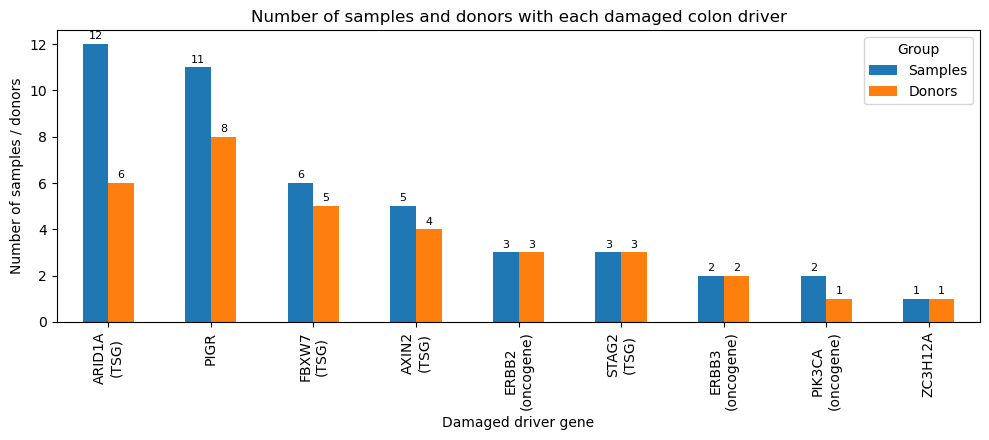

In [50]:
# ============================================================
# Number of samples and donors with each damaged colon driver
# ============================================================



# Create plot

ax = damaging_counts.plot(
    x="symbol_19807",
    y=["n_samples", "n_donors"],
    kind="bar",
    figsize=(10, 5)
)
# This creates the bar plot and stores the axis object.

ax.legend(
    ["Samples", "Donors"],
    title="Group"
)
# This replaces the default legend labels.

# Add values above bars

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%d",
        padding=2,
        fontsize=8
    )
    # This displays the exact count above each bar.

plt.ylabel("Number of samples / donors")
# This labels the y-axis.

plt.xlabel("Damaged driver gene")
# This labels the x-axis.

plt.title(
    "Number of samples and donors with each damaged colon driver"
)
# This adds the main plot title.


# This adds dataset summary statistics below the title.

gene_labels = make_gene_labels(
    damaging_counts["symbol_19807"].tolist()
)
# This creates gene labels with oncogene/TSG annotation.

plt.xticks(
    ticks=range(len(damaging_counts)),
    labels=gene_labels,
    rotation=90
)
# This labels the x-axis with gene names and canonical driver roles.

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)
# This leaves room for the figure text above the plot.

plt.savefig(
    OUT / "colon_damaged_driver_sample_donor_counts.png",
    dpi=300,
    bbox_inches="tight"
)
# This saves the figure.

plt.show()
# This displays the plot.

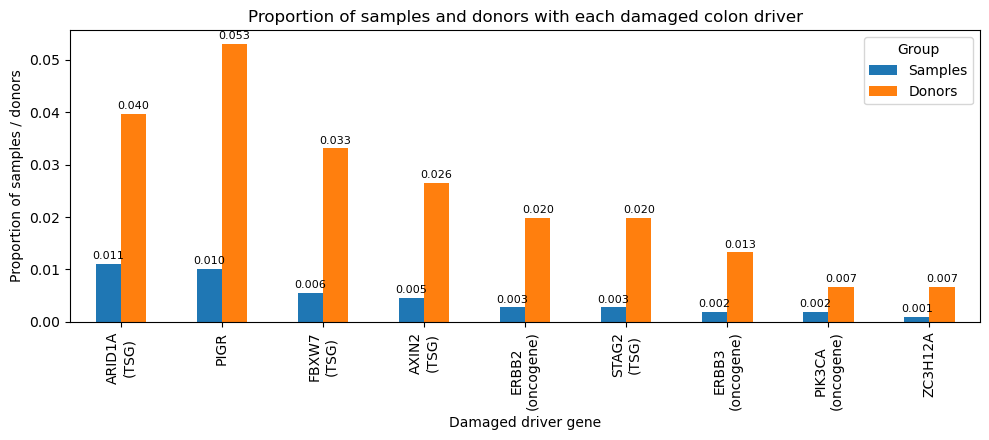

In [52]:
# ============================================================
# Proportion of samples and donors with each damaged colon driver
# ============================================================

# Calculate summary numbers

total_samples = mutation_data["Sample"].nunique()
# Total number of colon samples.

total_donors = mutation_data["IndividualID"].nunique()
# Total number of colon donors.

# Create proportion columns

damaging_counts_prop = damaging_counts.copy()
# This copies the damaged driver count table.

damaging_counts_prop["prop_samples"] = (
    damaging_counts_prop["n_samples"] / total_samples
)
# This calculates the proportion of all samples containing each damaged driver.

damaging_counts_prop["prop_donors"] = (
    damaging_counts_prop["n_donors"] / total_donors
)
# This calculates the proportion of all donors containing each damaged driver.

# Create plot

ax = damaging_counts_prop.plot(
    x="symbol_19807",
    y=["prop_samples", "prop_donors"],
    kind="bar",
    figsize=(10, 5)
)

ax.legend(
    ["Samples", "Donors"],
    title="Group"
)

# Add proportion values above bars

for container in ax.containers:

    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2,
        fontsize=8
    )

ax.set_ylabel("Proportion of samples / donors")

ax.set_xlabel("Damaged driver gene")

ax.set_title(
    "Proportion of samples and donors with each damaged colon driver"
)



gene_labels = make_gene_labels(
    damaging_counts_prop["symbol_19807"].tolist()
)

ax.set_xticks(range(len(damaging_counts_prop)))

ax.set_xticklabels(
    gene_labels,
    rotation=90
)

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)

plt.savefig(
    OUT / "colon_damaged_driver_sample_donor_proportions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
#Proportion of samples/donors with 0, 1, 2, 3, >3 damaged drivers

all_samples = mutation_data["Sample"].dropna().unique()
# This stores all samples in the mutation dataset.

#for donors
all_donors = mutation_data["IndividualID"].dropna().unique()
# This stores all donors in the mutation dataset.

donor_driver_counts = (
    driver_mutations
    .groupby("IndividualID")["symbol_19807"]
    .nunique()
    .reindex(all_donors, fill_value=0)
    .reset_index()
)
# This counts how many unique driver genes are mutated per donor.


sample_driver_counts = (
    driver_mutations
    .groupby("Sample")["symbol_19807"]
    .nunique()
    .reindex(all_samples, fill_value=0)
    .reset_index()
)
# This counts how many unique driver genes are mutated per sample.

sample_damaged_counts = (
    damaging_driver_mutations
    .groupby("Sample")["symbol_19807"]
    .nunique()
    .reindex(all_samples, fill_value=0)
    .reset_index()
)
# This counts damaged driver genes per sample.

sample_damaged_counts.columns = ["Sample", "n_damaged_drivers"]
# This renames columns.

sample_damaged_counts["driver_group"] = sample_damaged_counts["n_damaged_drivers"].apply(
    lambda x: ">3" if x > 3 else str(x)
)
# This groups samples into 0, 1, 2, 3, and >3 damaged drivers.

sample_damaged_prop = (
    sample_damaged_counts["driver_group"]
    .value_counts(normalize=True)
    .reindex(["0", "1", "2", "3", ">3"], fill_value=0)
    .reset_index()
)
# This calculates sample proportions.

sample_damaged_prop.columns = ["driver_group", "proportion"]
# This renames columns.

In [54]:
donor_damaged_counts = (
    damaging_driver_mutations
    .groupby("IndividualID")["symbol_19807"]
    .nunique()
    .reindex(all_donors, fill_value=0)
    .reset_index()
)
# This counts damaged driver genes per donor.

donor_damaged_counts.columns = ["IndividualID", "n_damaged_drivers"]
# This renames columns.

donor_damaged_counts["driver_group"] = donor_damaged_counts["n_damaged_drivers"].apply(
    lambda x: ">3" if x > 3 else str(x)
)
# This groups donors into 0, 1, 2, 3, and >3 damaged drivers.

donor_damaged_prop = (
    donor_damaged_counts["driver_group"]
    .value_counts(normalize=True)
    .reindex(["0", "1", "2", "3", ">3"], fill_value=0)
    .reset_index()
)
# This calculates donor proportions.

donor_damaged_prop.columns = ["driver_group", "proportion"]
# This renames columns.

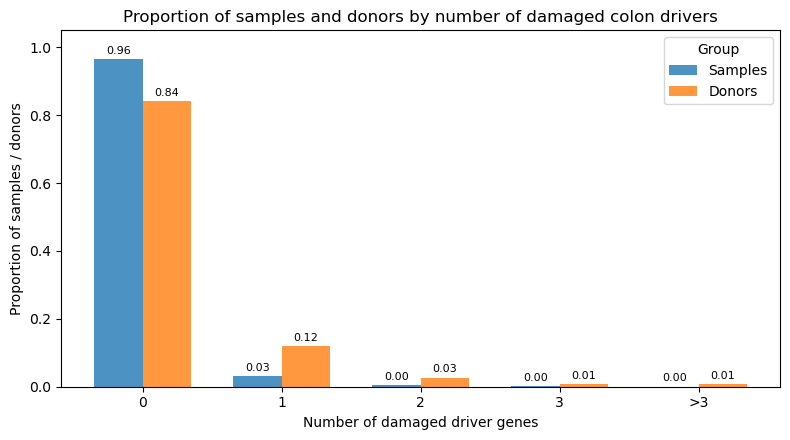

In [55]:
# ============================================================
# Proportion of samples and donors by number of damaged drivers
# ============================================================


# Create figure

fig, ax = plt.subplots(figsize=(8, 5))

# Define x-axis positions

x = np.arange(len(sample_damaged_prop))

width = 0.35

# Sample bars

sample_bars = ax.bar(
    x - width/2,
    sample_damaged_prop["proportion"],
    width,
    label="Samples",
    alpha=0.8
)

# Donor bars

donor_bars = ax.bar(
    x + width/2,
    donor_damaged_prop["proportion"],
    width,
    label="Donors",
    alpha=0.8
)

# Add values above sample bars

for bar in sample_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Add values above donor bars

for bar in donor_bars:

    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8
    )

# Leave space above tallest bars

ax.set_ylim(0, 1.05)

# Axis labels

ax.set_xticks(x)

ax.set_xticklabels(
    sample_damaged_prop["driver_group"]
)

ax.set_xlabel("Number of damaged driver genes")

ax.set_ylabel("Proportion of samples / donors")

ax.set_title(
    "Proportion of samples and donors by number of damaged colon drivers"
)

# Add dataset summary statistics



ax.legend(title="Group")

plt.tight_layout(
    rect=[0, 0, 1, 0.90]
)

plt.savefig(
    OUT / "colon_proportion_samples_donors_damaged_drivers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [56]:
# ============================================================
# Relationship between donor age and damaged driver burden
# ============================================================

# Count unique damaged driver genes per donor

donor_damaged_counts = (
    damaging_driver_mutations
    .groupby("IndividualID")["symbol_19807"]
    .nunique()
    .reset_index(name="n_damaged_drivers")
)
# This counts how many unique damaged driver genes are observed in each donor.

# Create donor metadata table

donor_metadata = (
    sample_metadata[
        ["IndividualID", "Age"]
    ]
    .drop_duplicates()
)
# This keeps one row per donor with age information.

# Merge donor age with damaged driver burden

donor_damaged_counts = donor_metadata.merge(
    donor_damaged_counts,
    on="IndividualID",
    how="left"
)
# This adds damaged driver burden to every donor.
# Donors with no damaged driver genes will have missing values.

# Replace missing damaged driver counts with 0

donor_damaged_counts["n_damaged_drivers"] = (
    donor_damaged_counts["n_damaged_drivers"]
    .fillna(0)
    .astype(int)
)
# This assigns 0 damaged drivers to donors without damaged driver mutations.

# Convert age to numeric

donor_damaged_counts["Age"] = pd.to_numeric(
    donor_damaged_counts["Age"],
    errors="coerce"
)
# This makes sure age is treated as a number.

# Remove donors with missing age

donor_damaged_counts = donor_damaged_counts.dropna(
    subset=["Age"]
)
# This removes donors without age information.

# Sort by age

donor_damaged_counts = donor_damaged_counts.sort_values("Age")
# This orders donors by age for cleaner plotting.

display(donor_damaged_counts.head())

,IndividualID,Age,n_damaged_drivers
4,STE0120,9,0
113,312,11,0
148,PD34202,13,0
112,300,15,0
3,STE0116,15,0


Slope = 0.0010
R² = 0.0009
P-value = 0.7223


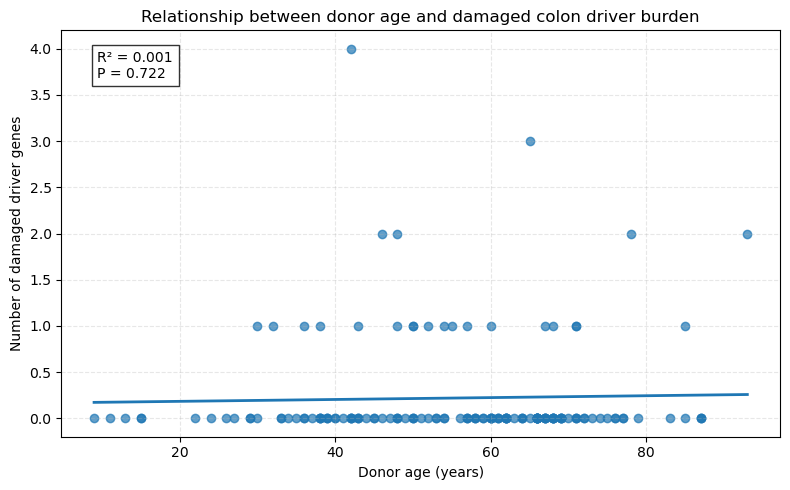

In [57]:
# ============================================================
# Scatter plot with linear regression
# Damaged driver burden by donor age
# ============================================================

from scipy.stats import linregress

# Use existing donor damaged counts table

plot_data = donor_damaged_counts.dropna(
    subset=["Age", "n_damaged_drivers"]
)

# Fit linear regression

regression = linregress(
    plot_data["Age"],
    plot_data["n_damaged_drivers"]
)

slope = regression.slope
intercept = regression.intercept
r_value = regression.rvalue
r_squared = r_value ** 2
p_value = regression.pvalue

print(f"Slope = {slope:.4f}")
print(f"R² = {r_squared:.4f}")
print(f"P-value = {p_value:.4f}")

# Create figure

fig, ax = plt.subplots(figsize=(8, 5))

# Scatter plot

ax.scatter(
    plot_data["Age"],
    plot_data["n_damaged_drivers"],
    alpha=0.7
)

# Regression line

x = np.linspace(
    plot_data["Age"].min(),
    plot_data["Age"].max(),
    100
)

y = intercept + slope * x

ax.plot(
    x,
    y,
    linewidth=2
)

# Labels

ax.set_xlabel("Donor age (years)")
ax.set_ylabel("Number of damaged driver genes")

ax.set_title(
    "Relationship between donor age and damaged colon driver burden"
)

# Add regression statistics

ax.text(
    0.05,
    0.95,
    f"R² = {r_squared:.3f}\n"
    f"P = {p_value:.3f}",
    transform=ax.transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

ax.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    OUT / "age_vs_damaged_driver_burden_regression.png",
    dpi=300
)

plt.show()

In [58]:
#Classify damaging mutations as LoF, GoF, or nonsynonymous

lof_terms = [
    "frameshift deletion",
    "frameshift insertion",
    "frameshift substitution",
    "stopgain",
    "stoploss"
]
# These mutation types are treated as loss-of-function.

def classify_mutation(row):
    if row["ExonicFunc.refGene"] in lof_terms:
        return "Loss of function"
    elif row["is_hotspot"] == True:
        return "Gain of function"
    else:
        return "Nonsynonymous"
# This classifies damaging/hotspot mutations into broad functional categories.

damaging_driver_mutations["mutation_class"] = damaging_driver_mutations.apply(
    classify_mutation,
    axis=1
)
# This applies the classification to every mutation.

damaging_driver_mutations[
    ["symbol_19807", "ExonicFunc.refGene", "is_hotspot", "mutation_class"]
].head()

,symbol_19807,ExonicFunc.refGene,is_hotspot,mutation_class
15568,STAG2,frameshift substitution,False,Loss of function
15569,STAG2,frameshift substitution,False,Loss of function
17873,PIGR,splicing,False,Nonsynonymous
18628,STAG2,stopgain,False,Loss of function
154287,AXIN2,nonsynonymous,False,Nonsynonymous


In [59]:
#Count mutation classes per driver
mutation_class_counts = (
    damaging_driver_mutations
    .groupby(["symbol_19807", "mutation_class"])
    .size()
    .reset_index(name="n_muts")
)
# This counts LoF, GoF, and nonsynonymous mutations per driver gene.

mutation_class_counts

,symbol_19807,mutation_class,n_muts
0,ARID1A,Loss of function,9
1,ARID1A,Nonsynonymous,3
2,AXIN2,Loss of function,4
3,AXIN2,Nonsynonymous,1
4,ERBB2,Gain of function,2
5,ERBB2,Nonsynonymous,1
6,ERBB3,Nonsynonymous,2
7,FBXW7,Gain of function,3
8,FBXW7,Loss of function,2
9,FBXW7,Nonsynonymous,2


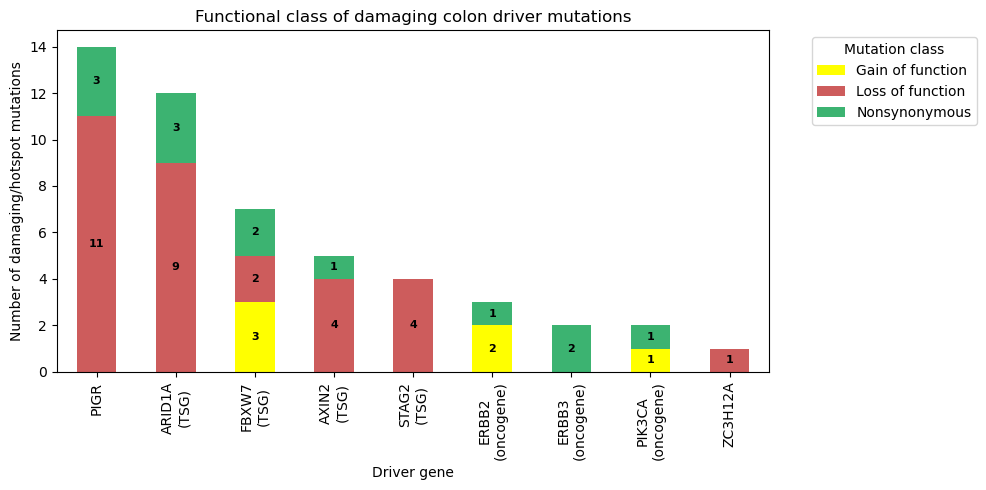

In [60]:
# ============================================================
# Functional class of damaging colon driver mutations
# Stacked barplot showing mutation counts
# ============================================================

# Define mutation class order

mutation_order = [
    "Gain of function",
    "Loss of function",
    "Nonsynonymous"
]

# Create wide count table

mutation_class_counts_wide = (
    mutation_class_counts
    .pivot(
        index="symbol_19807",
        columns="mutation_class",
        values="n_muts"
    )
    .fillna(0)
)

mutation_class_counts_wide = mutation_class_counts_wide.reindex(
    columns=mutation_order,
    fill_value=0
)

# Order genes by total mutations

gene_order = (
    mutation_class_counts
    .groupby("symbol_19807")["n_muts"]
    .sum()
    .sort_values(ascending=False)
    .index
)

mutation_class_counts_wide = mutation_class_counts_wide.loc[gene_order]

# Create stacked count plot

ax = mutation_class_counts_wide.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5),
    color=[
        "yellow",
        "indianred",
        "mediumseagreen"
    ]
)

# Add count labels

for i, gene in enumerate(mutation_class_counts_wide.index):

    cumulative_height = 0

    for mutation_class in mutation_class_counts_wide.columns:

        count = int(
            mutation_class_counts_wide.loc[
                gene,
                mutation_class
            ]
        )

        if count == 0:
            continue

        y_position = cumulative_height + (count / 2)

        ax.text(
            i,
            y_position,
            str(count),
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold"
        )

        cumulative_height += count

# Add gene labels

gene_labels = make_gene_labels(
    mutation_class_counts_wide.index.tolist()
)

ax.set_xticks(range(len(mutation_class_counts_wide.index)))

ax.set_xticklabels(
    gene_labels,
    rotation=90
)

ax.set_ylabel("Number of damaging/hotspot mutations")

ax.set_xlabel("Driver gene")

ax.set_title(
    "Functional class of damaging colon driver mutations"
)

ax.legend(
    title="Mutation class",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    OUT / "colon_driver_mutation_function_stacked_barplot_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
total_samples = mutation_data["Sample"].nunique()
damaged_samples = damaging_driver_mutations["Sample"].nunique()

total_donors = mutation_data["IndividualID"].nunique()
damaged_donors = damaging_driver_mutations["IndividualID"].nunique()

print("Total samples:", total_samples)
print("Samples with damaging driver mutations:",
      damaged_samples, f"({damaged_samples / total_samples * 100:.1f}%)")

print("Total donors:", total_donors)
print("Donors with damaging driver mutations:",
      damaged_donors, f"({damaged_donors / total_donors * 100:.1f}%)")

Total samples: 1087
Samples with damaging driver mutations: 39 (3.6%)
Total donors: 151
Donors with damaging driver mutations: 24 (15.9%)
